In [79]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load dataset
df = pd.read_csv("/content/exchange_rate.csv")

# Convert date column to datetime
df["date"] = pd.to_datetime(
    df["date"],
    dayfirst=True
)

# Sort by date
df = df.sort_values("date")

# Set date as index
df = df.set_index("date")

# Check dataset
print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nData Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Dates:", df.index.duplicated().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (7588, 1)

First 5 Rows:


,Ex_rate
date,
1990-01-01,0.7855
1990-01-02,0.7818
1990-01-03,0.7867
1990-01-04,0.7860
1990-01-05,0.7849



Data Information:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7588 entries, 1990-01-01 to 2010-10-10
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Ex_rate  7588 non-null   float64
dtypes: float64(1)
memory usage: 118.6 KB

Missing Values:
Ex_rate    0
dtype: int64

Duplicate Dates: 0

Statistical Summary:


,Ex_rate
count,7588.000000
mean,0.776974
std,0.136620
min,0.483297
25%,0.701422
50%,0.761377
75%,0.873477
max,1.102536


Missing values after preprocessing:
Ex_rate    0
dtype: int64


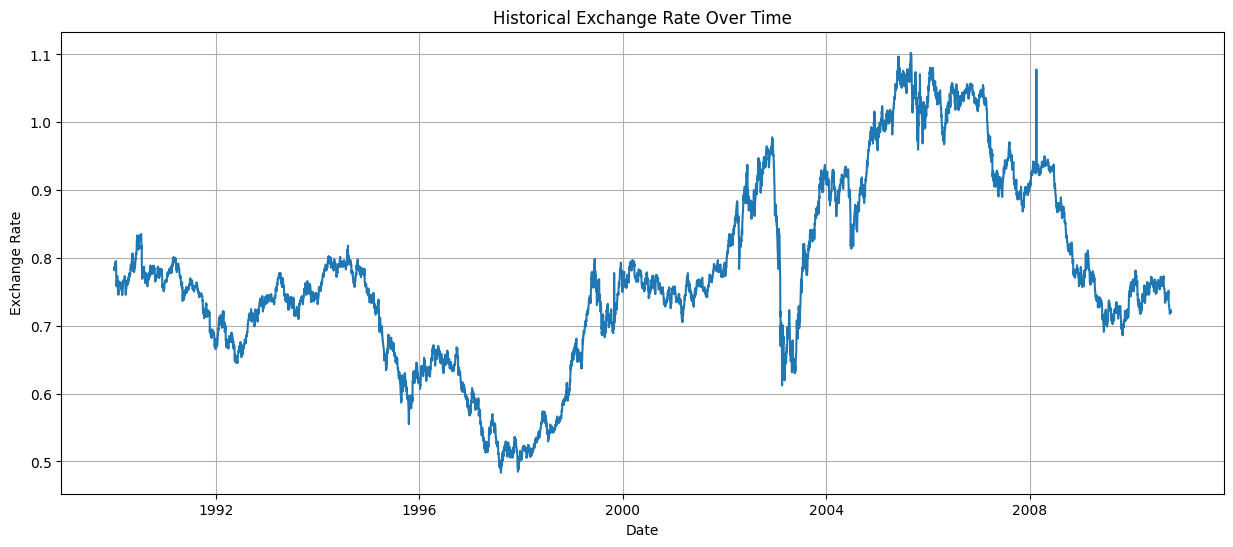

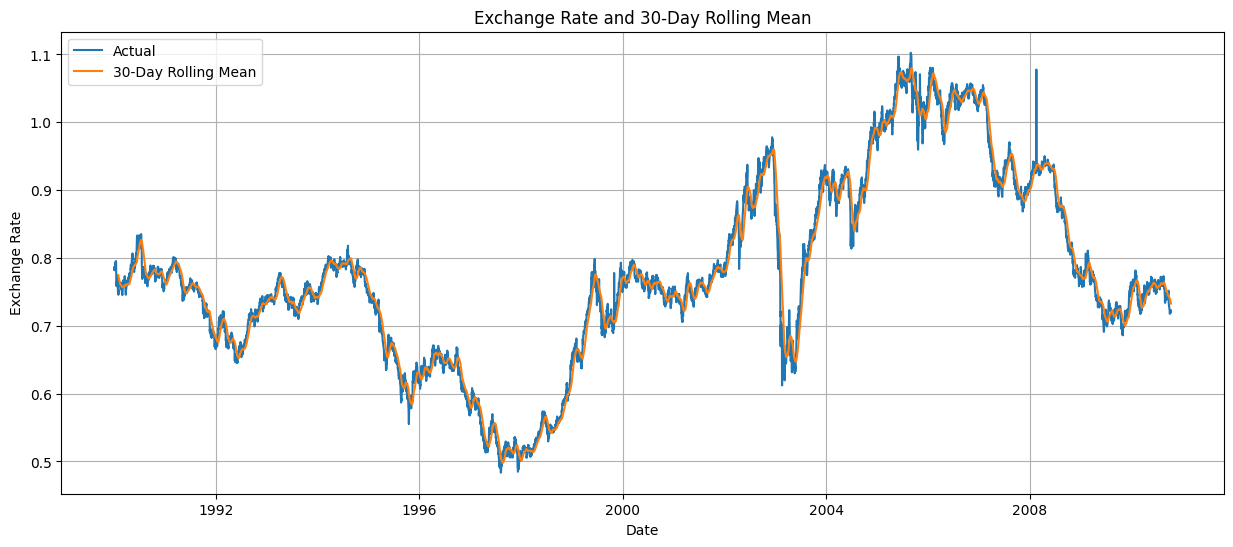

In [80]:
# Handle missing values
df["Ex_rate"] = df["Ex_rate"].interpolate(
    method="time"
)

# If missing values remain at the beginning/end
df["Ex_rate"] = df["Ex_rate"].ffill().bfill()

print("Missing values after preprocessing:")
print(df.isnull().sum())

# Plot exchange rate
plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Ex_rate"]
)

plt.title(
    "Historical Exchange Rate Over Time"
)

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.grid()

plt.show()

# Rolling mean to observe trend
rolling_mean = df["Ex_rate"].rolling(
    window=30
).mean()

plt.figure(figsize=(15, 6))

plt.plot(
    df.index,
    df["Ex_rate"],
    label="Actual"
)

plt.plot(
    df.index,
    rolling_mean,
    label="30-Day Rolling Mean"
)

plt.title(
    "Exchange Rate and 30-Day Rolling Mean"
)

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid()

plt.show()

ADF Test - Original Series
ADF Statistic: -1.6649941807382342
p-value: 0.4492327353597477

ADF Test - First Difference
ADF Statistic: -99.39343120118632
p-value: 0.0


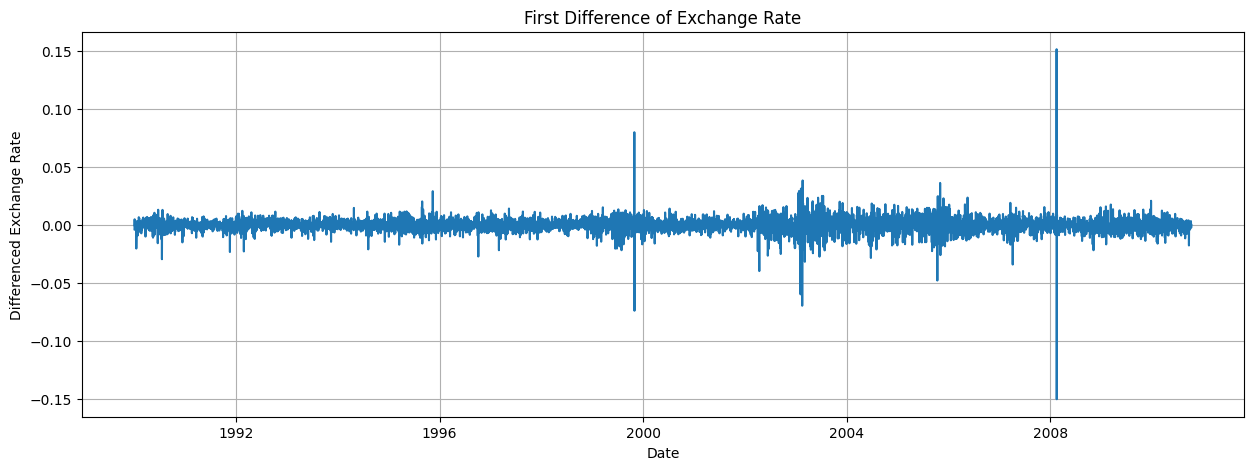

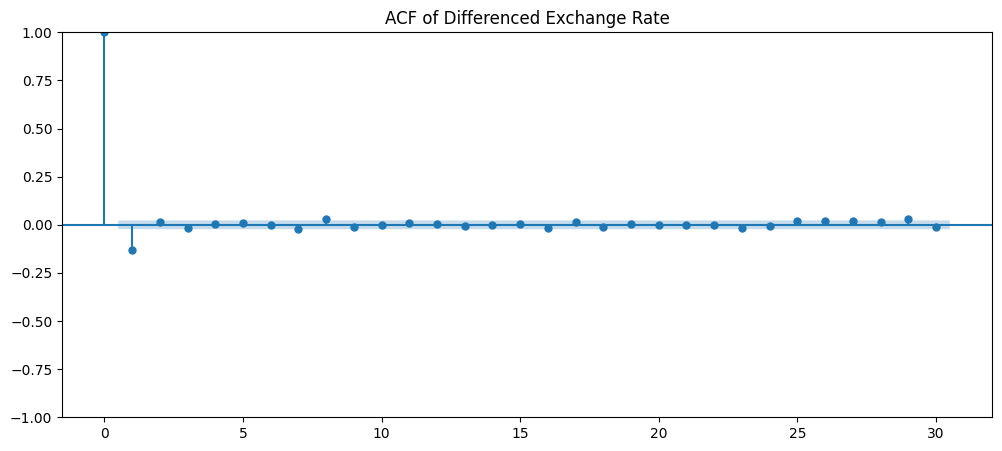

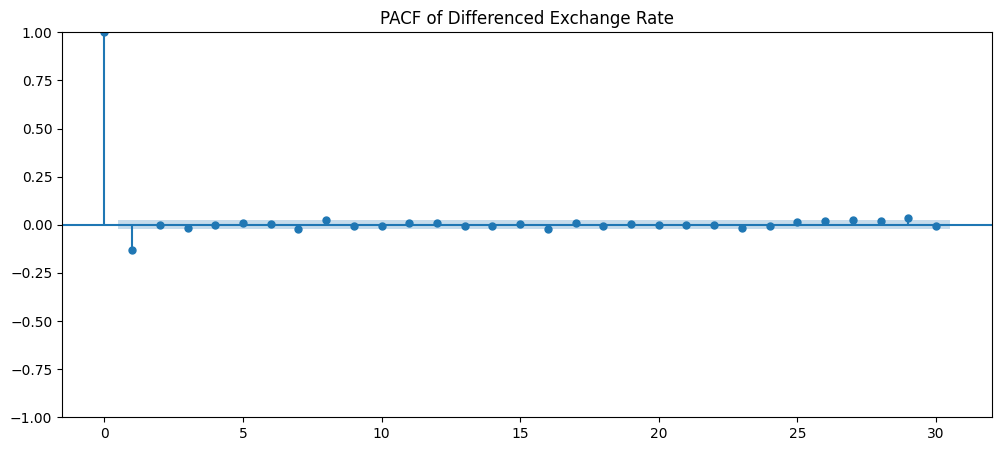


Training observations: 6070
Testing observations: 1518


In [81]:
from statsmodels.tsa.stattools import adfuller

# Original series
series = df["Ex_rate"]

# Augmented Dickey-Fuller test
adf_original = adfuller(series)

print("ADF Test - Original Series")
print("ADF Statistic:", adf_original[0])
print("p-value:", adf_original[1])

# First difference
diff_series = series.diff().dropna()

adf_diff = adfuller(diff_series)

print("\nADF Test - First Difference")
print("ADF Statistic:", adf_diff[0])
print("p-value:", adf_diff[1])

# Plot differenced series
plt.figure(figsize=(15, 5))

plt.plot(diff_series)

plt.title(
    "First Difference of Exchange Rate"
)

plt.xlabel("Date")
plt.ylabel("Differenced Exchange Rate")

plt.grid()

plt.show()

# ACF
fig, ax = plt.subplots(figsize=(12, 5))

plot_acf(
    diff_series,
    lags=30,
    ax=ax
)

plt.title(
    "ACF of Differenced Exchange Rate"
)

plt.show()

# PACF
fig, ax = plt.subplots(figsize=(12, 5))

plot_pacf(
    diff_series,
    lags=30,
    ax=ax,
    method="ywm"
)

plt.title(
    "PACF of Differenced Exchange Rate"
)

plt.show()

# -----------------------------
# Train/Test Split
# -----------------------------

train_size = int(
    len(series) * 0.80
)

train = series.iloc[:train_size]
test = series.iloc[train_size:]

print("\nTraining observations:", len(train))
print("Testing observations:", len(test))

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                Ex_rate   No. Observations:                 6070
Model:                 ARIMA(1, 1, 1)   Log Likelihood               22719.046
Date:                Tue, 25 Aug 2026   AIC                         -45432.092
Time:                        16:41:18   BIC                         -45411.959
Sample:                    01-01-1990   HQIC                        -45425.104
                         - 08-14-2006                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5972      0.062     -9.648      0.000      -0.719      -0.476
ma.L1          0.5398      0.064      8.430      0.000       0.414       0.665
sigma2      3.281e-05   1.95e-07    168.198      0.0

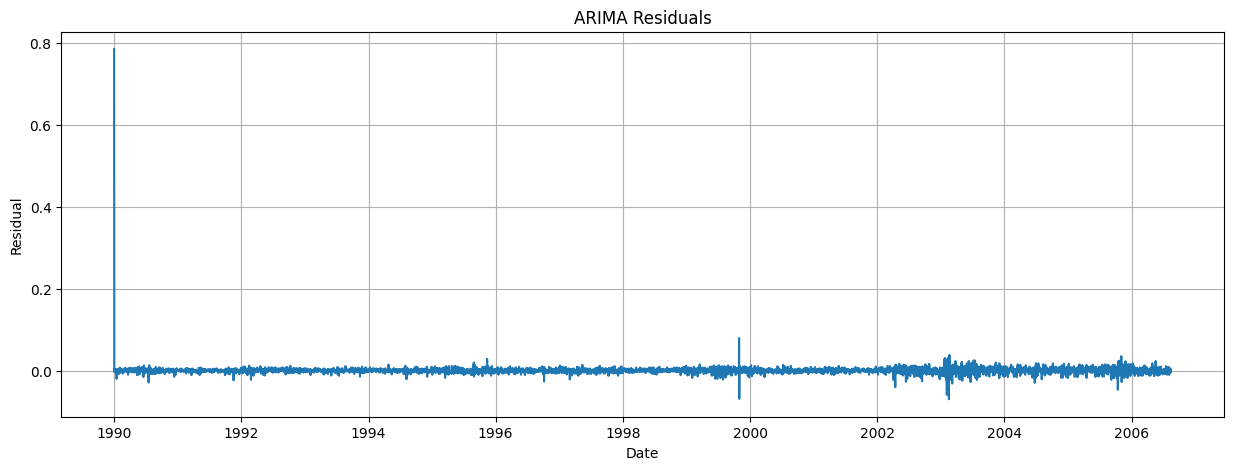

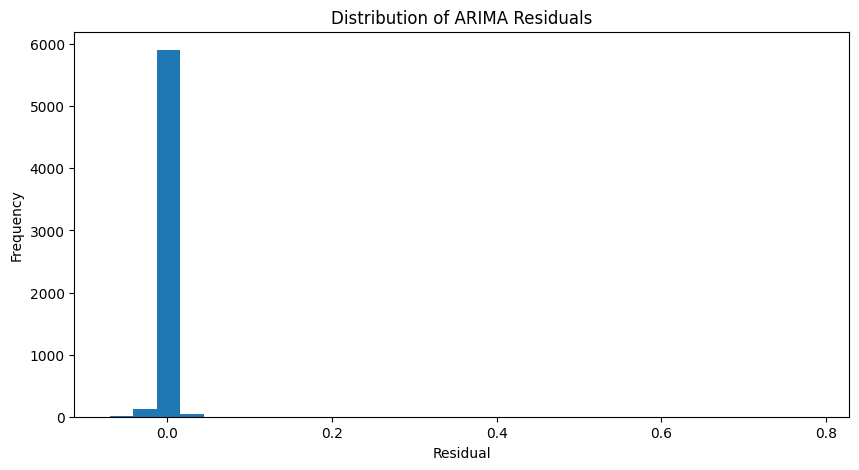

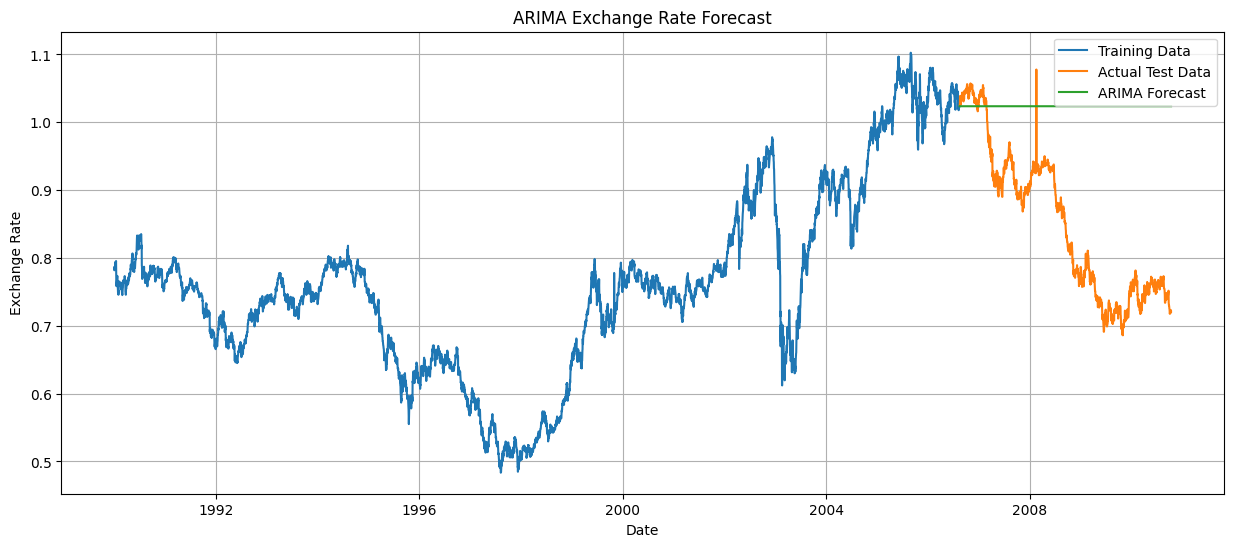

In [82]:
# -----------------------------
# ARIMA(1,1,1)
# -----------------------------

arima_model = ARIMA(
    train,
    order=(1, 1, 1)
)

arima_result = arima_model.fit()

print(arima_result.summary())

# -----------------------------
# Residual Diagnostics
# -----------------------------

residuals = arima_result.resid

plt.figure(figsize=(15, 5))

plt.plot(residuals)

plt.title(
    "ARIMA Residuals"
)

plt.xlabel("Date")
plt.ylabel("Residual")

plt.grid()

plt.show()

# Residual histogram
plt.figure(figsize=(10, 5))

plt.hist(
    residuals,
    bins=30
)

plt.title(
    "Distribution of ARIMA Residuals"
)

plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

# -----------------------------
# Forecast
# -----------------------------

arima_forecast = arima_result.forecast(
    steps=len(test)
)

plt.figure(figsize=(15, 6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Test Data"
)

plt.plot(
    test.index,
    arima_forecast,
    label="ARIMA Forecast"
)

plt.title(
    "ARIMA Exchange Rate Forecast"
)

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid()

plt.show()

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


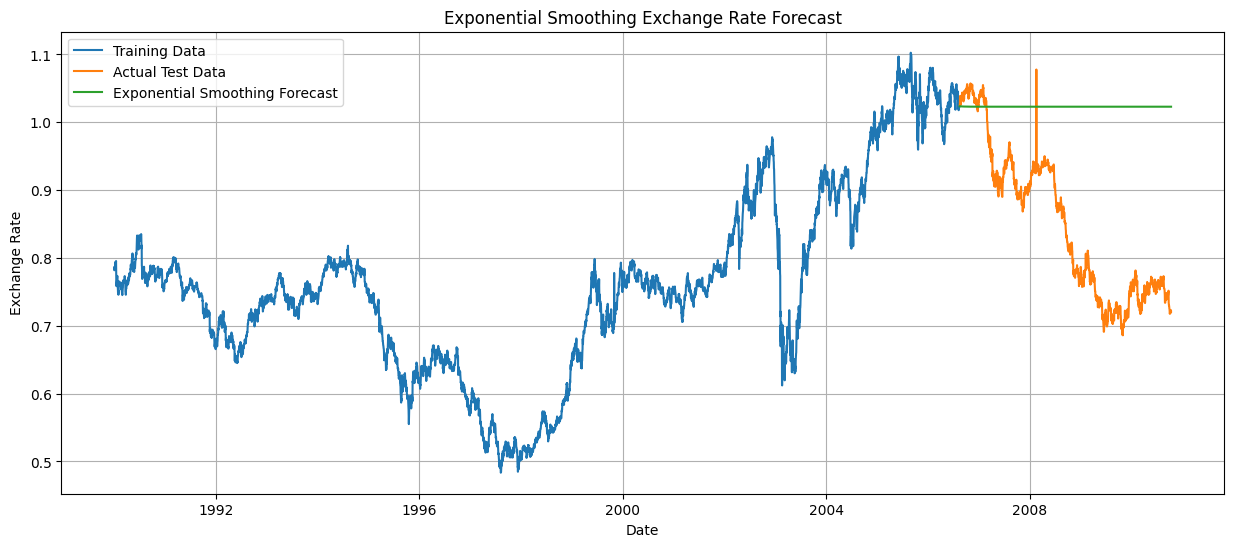

,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1,1,1)",0.17771,0.205437,22.797966
1,Exponential Smoothing,0.17718,0.204855,22.730926


In [83]:
# -----------------------------
# Exponential Smoothing
# -----------------------------

exp_model = ExponentialSmoothing(
    train,
    trend="add",
    damped_trend=True,
    seasonal=None
)

exp_result = exp_model.fit(
    optimized=True
)

# Forecast
exp_forecast = exp_result.forecast(
    steps=len(test)
)

# -----------------------------
# Plot Forecast
# -----------------------------

plt.figure(figsize=(15, 6))

plt.plot(
    train.index,
    train,
    label="Training Data"
)

plt.plot(
    test.index,
    test,
    label="Actual Test Data"
)

plt.plot(
    test.index,
    exp_forecast,
    label="Exponential Smoothing Forecast"
)

plt.title(
    "Exponential Smoothing Exchange Rate Forecast"
)

plt.xlabel("Date")
plt.ylabel("Exchange Rate")

plt.legend()
plt.grid()

plt.show()

# -----------------------------
# Evaluation Function
# -----------------------------

def calculate_metrics(actual, predicted):

    mae = mean_absolute_error(
        actual,
        predicted
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predicted
        )
    )

    mape = np.mean(
        np.abs(
            (actual - predicted) / actual
        )
    ) * 100

    return mae, rmse, mape


# ARIMA Metrics
arima_mae, arima_rmse, arima_mape = calculate_metrics(
    test,
    arima_forecast
)

# Exponential Smoothing Metrics
exp_mae, exp_rmse, exp_mape = calculate_metrics(
    test,
    exp_forecast
)

# Comparison table
comparison = pd.DataFrame({
    "Model": [
        "ARIMA(1,1,1)",
        "Exponential Smoothing"
    ],
    "MAE": [
        arima_mae,
        exp_mae
    ],
    "RMSE": [
        arima_rmse,
        exp_rmse
    ],
    "MAPE (%)": [
        arima_mape,
        exp_mape
    ]
})

display(
    comparison.round(6)
)

# Model Comparison and Conclusion

## Model Comparison

ARIMA and Exponential Smoothing were evaluated using Mean Absolute Error
(MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error
(MAPE).

For all three metrics, lower values indicate better forecasting performance.

ARIMA is useful when the time series contains autocorrelation and
differencing is required to achieve stationarity.

Exponential Smoothing is useful when the series contains level and trend
components and recent observations should receive greater importance.

## Conclusion

The exchange-rate dataset was successfully prepared and analyzed as a
time-series dataset.

The historical exchange rate was visualized to understand its movement over
time. Missing observations were handled using time-based interpolation.

ACF and PACF plots were examined after first differencing to help identify
initial ARIMA parameters. An ARIMA(1,1,1) model was fitted and its residuals
were examined.

An Exponential Smoothing model with a damped trend was also fitted and used
for out-of-sample forecasting.

Both models were evaluated using MAE, RMSE, and MAPE. The model with the
lowest error metrics provides the better forecasting performance on the
testing data.

The final model selection should therefore be based on the observed
out-of-sample error metrics rather than assuming that one forecasting method
will always perform better.

### Practical Implication

Accurate exchange-rate forecasting can support financial planning,
international trade decisions, budgeting, and risk management. However,
exchange rates are influenced by many external economic and geopolitical
factors, so forecasts should be interpreted together with broader economic
information.

In [84]:
# Identify the best model based on RMSE

best_model = comparison.loc[
    comparison["RMSE"].idxmin(),
    "Model"
]

print("Best Model based on RMSE:", best_model)

print("\nFinal Comparison:")
display(comparison.round(6))

Best Model based on RMSE: Exponential Smoothing

Final Comparison:


,Model,MAE,RMSE,MAPE (%)
0,"ARIMA(1,1,1)",0.17771,0.205437,22.797966
1,Exponential Smoothing,0.17718,0.204855,22.730926
